In [2]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt

In [12]:
import seaborn as sns

# Problem Definition:
Financial institutions face financial losses when credit card customers fail to repay their dues. Therefore, predicting customers who are likely to default can help financial institutions assess credit risk and take preventive actions.

In [3]:
df=pd.read_csv("C:\\Users\\haree\\Downloads\\Credit_card_default_prediction\\Credit Card Defaulter Prediction.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,F,University,Married,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,Y
1,2,120000,F,University,Single,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,Y
2,3,90000,F,University,Single,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,N
3,4,50000,F,University,Married,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,N
4,5,50000,M,University,Married,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,N


In [14]:
df.shape

(30000, 25)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  str  
 3   EDUCATION  30000 non-null  str  
 4   MARRIAGE   30000 non-null  str  
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [8]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [9]:
df.drop_duplicates(inplace=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         30000 non-null  int64
 1   LIMIT_BAL  30000 non-null  int64
 2   SEX        30000 non-null  str  
 3   EDUCATION  30000 non-null  str  
 4   MARRIAGE   30000 non-null  str  
 5   AGE        30000 non-null  int64
 6   PAY_0      30000 non-null  int64
 7   PAY_2      30000 non-null  int64
 8   PAY_3      30000 non-null  int64
 9   PAY_4      30000 non-null  int64
 10  PAY_5      30000 non-null  int64
 11  PAY_6      30000 non-null  int64
 12  BILL_AMT1  30000 non-null  int64
 13  BILL_AMT2  30000 non-null  int64
 14  BILL_AMT3  30000 non-null  int64
 15  BILL_AMT4  30000 non-null  int64
 16  BILL_AMT5  30000 non-null  int64
 17  BILL_AMT6  30000 non-null  int64
 18  PAY_AMT1   30000 non-null  int64
 19  PAY_AMT2   30000 non-null  int64
 20  PAY_AMT3   30000 non-null  int64
 21  PAY_AMT4   30000 non-nu

In [15]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default '],
      dtype='str')

In [16]:
df.columns = df.columns.str.strip()

In [17]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [18]:
df['default'].value_counts()

default
N    23364
Y     6636
Name: count, dtype: int64

In [19]:
df['default'].value_counts(normalize=True) * 100

default
N    77.88
Y    22.12
Name: proportion, dtype: float64

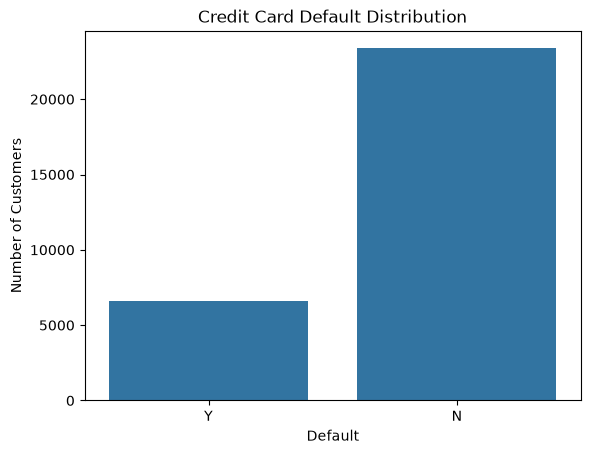

In [20]:
sns.countplot(x='default', data=df)
plt.title('Credit Card Default Distribution')
plt.xlabel('Default')
plt.ylabel('Number of Customers')
plt.show()

In [21]:
df['SEX'].value_counts()

SEX
F    18112
M    11888
Name: count, dtype: int64

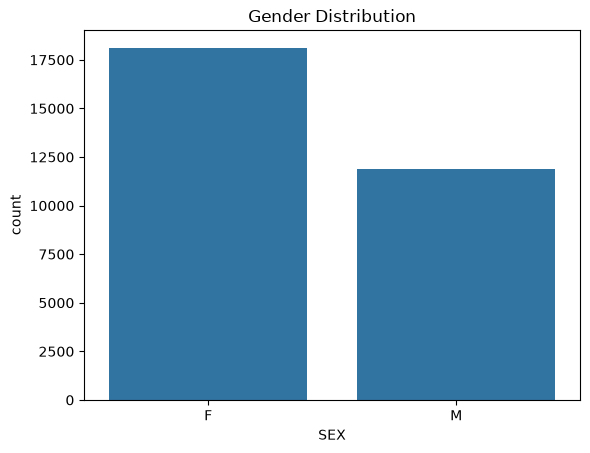

In [22]:
sns.countplot(x='SEX', data=df)
plt.title('Gender Distribution')
plt.show()

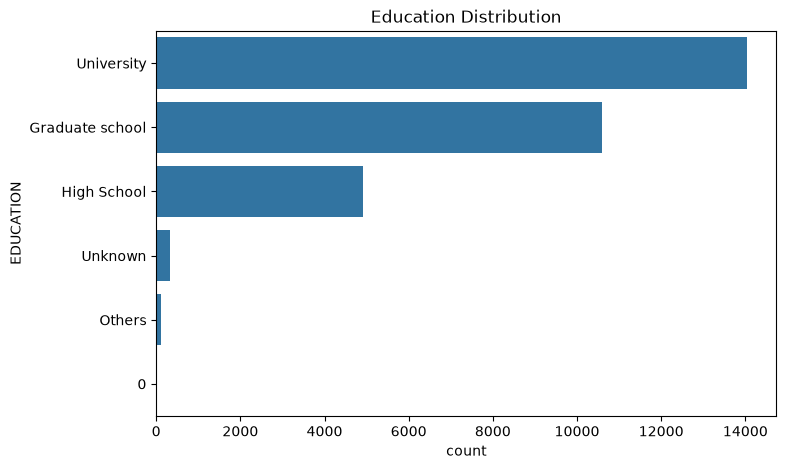

In [23]:
df['EDUCATION'].value_counts()
plt.figure(figsize=(8,5))

sns.countplot(
    y='EDUCATION',
    data=df,
    order=df['EDUCATION'].value_counts().index
)

plt.title('Education Distribution')
plt.show()

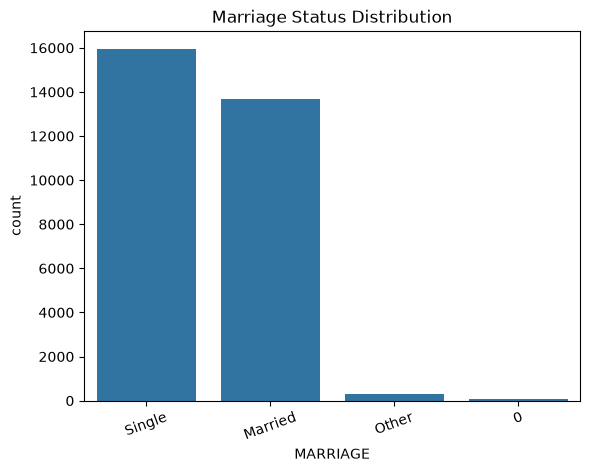

In [24]:
df['MARRIAGE'].value_counts()
sns.countplot(
    x='MARRIAGE',
    data=df,
    order=df['MARRIAGE'].value_counts().index
)

plt.title('Marriage Status Distribution')
plt.xticks(rotation=20)
plt.show()

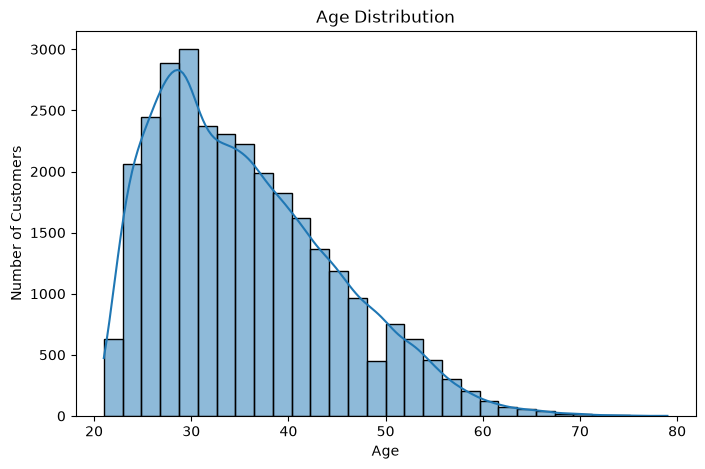

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df['AGE'], bins=30, kde=True)

plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.show()

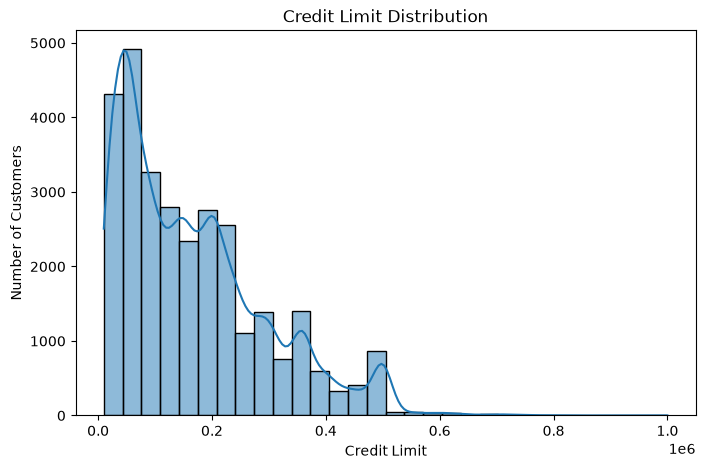

In [26]:
plt.figure(figsize=(8,5))

sns.histplot(df['LIMIT_BAL'], bins=30, kde=True)

plt.title('Credit Limit Distribution')
plt.xlabel('Credit Limit')
plt.ylabel('Number of Customers')
plt.show()

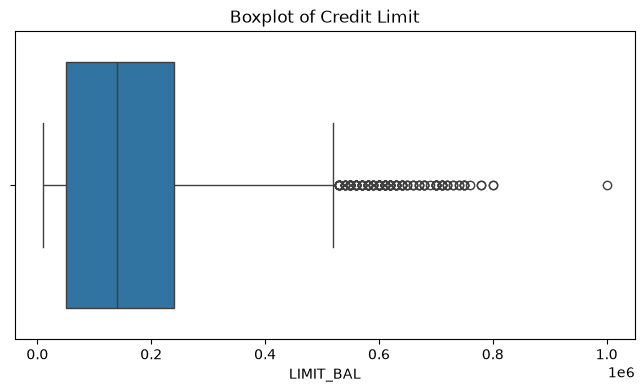

In [27]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['LIMIT_BAL'])

plt.title('Boxplot of Credit Limit')
plt.show()

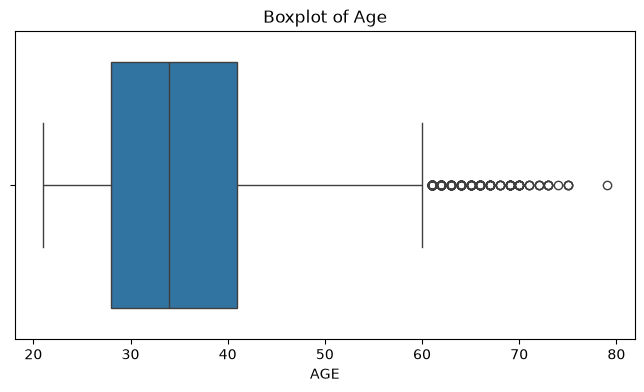

In [28]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['AGE'])

plt.title('Boxplot of Age')
plt.show()

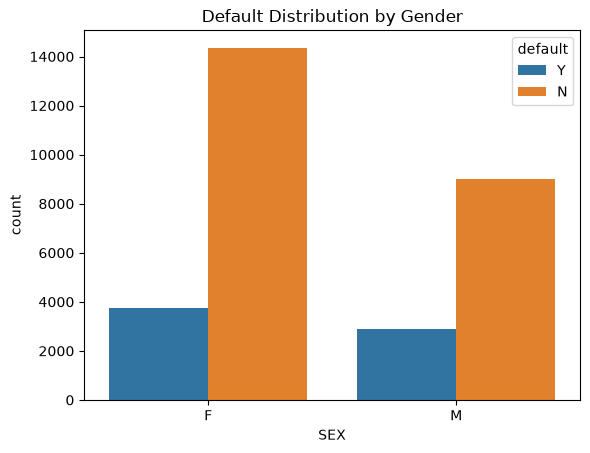

In [29]:
sns.countplot(x='SEX', hue='default', data=df)

plt.title('Default Distribution by Gender')
plt.show()

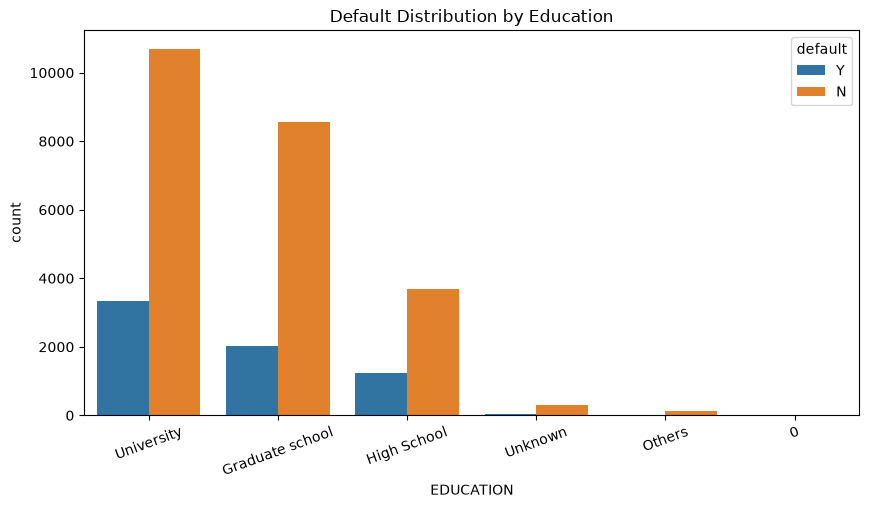

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='EDUCATION',
    hue='default',
    data=df
)

plt.title('Default Distribution by Education')
plt.xticks(rotation=20)
plt.show()

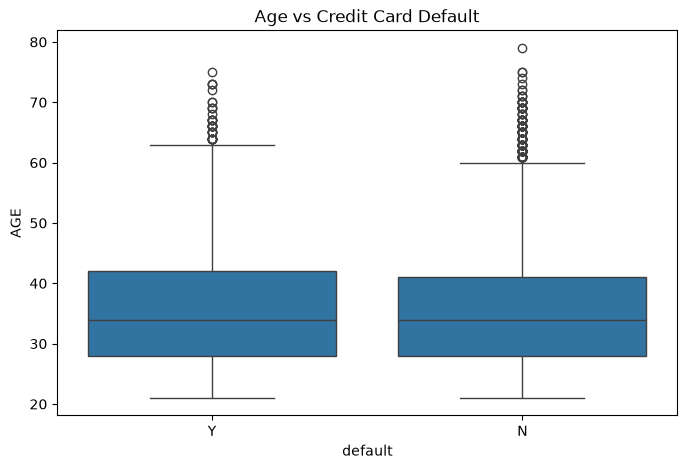

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='default',
    y='AGE',
    data=df
)

plt.title('Age vs Credit Card Default')
plt.show()

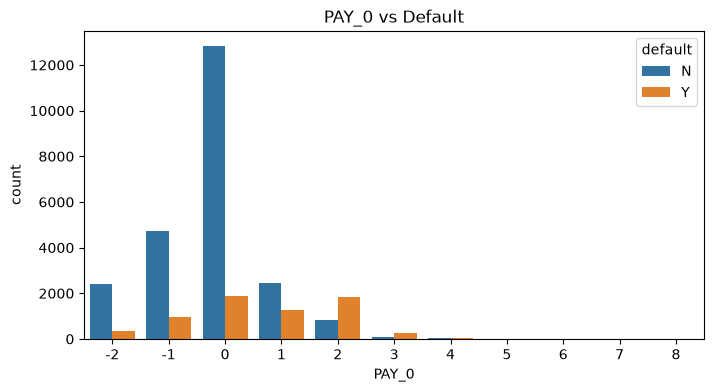

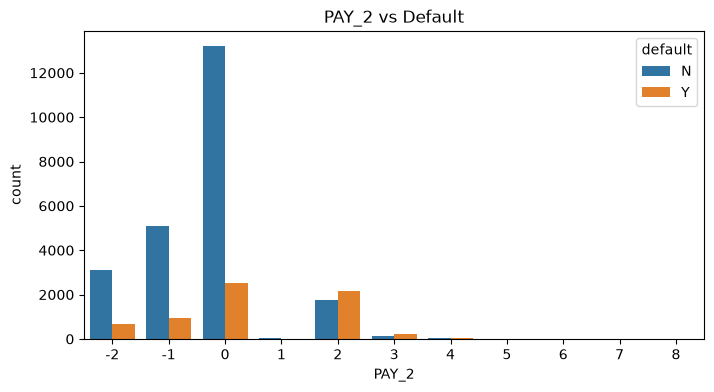

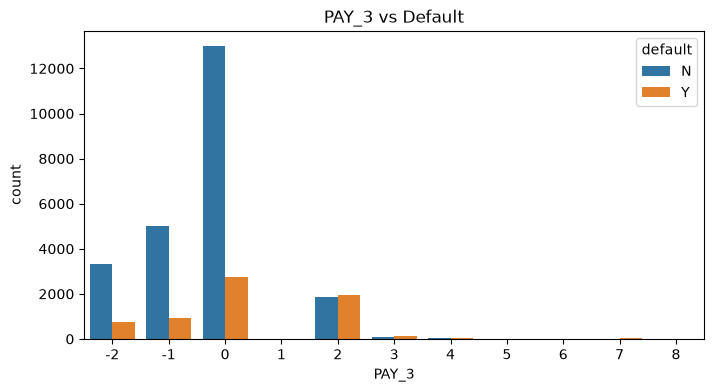

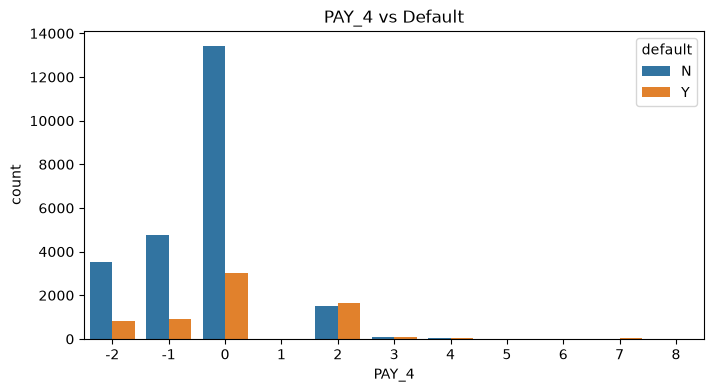

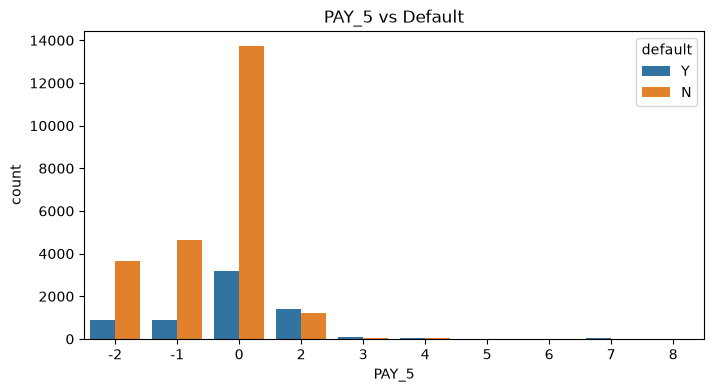

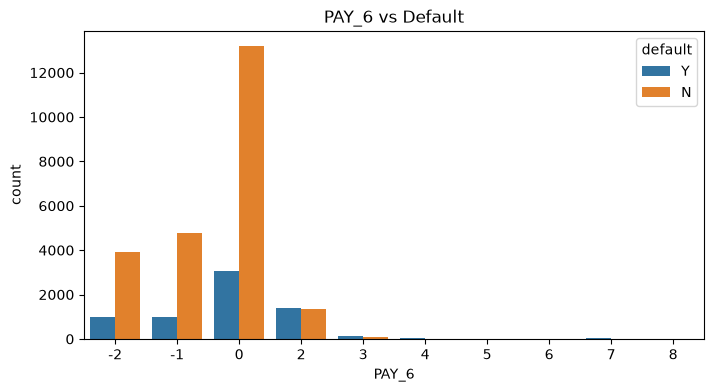

In [33]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in pay_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='default', data=df)
    plt.title(f'{col} vs Default')
    plt.show()

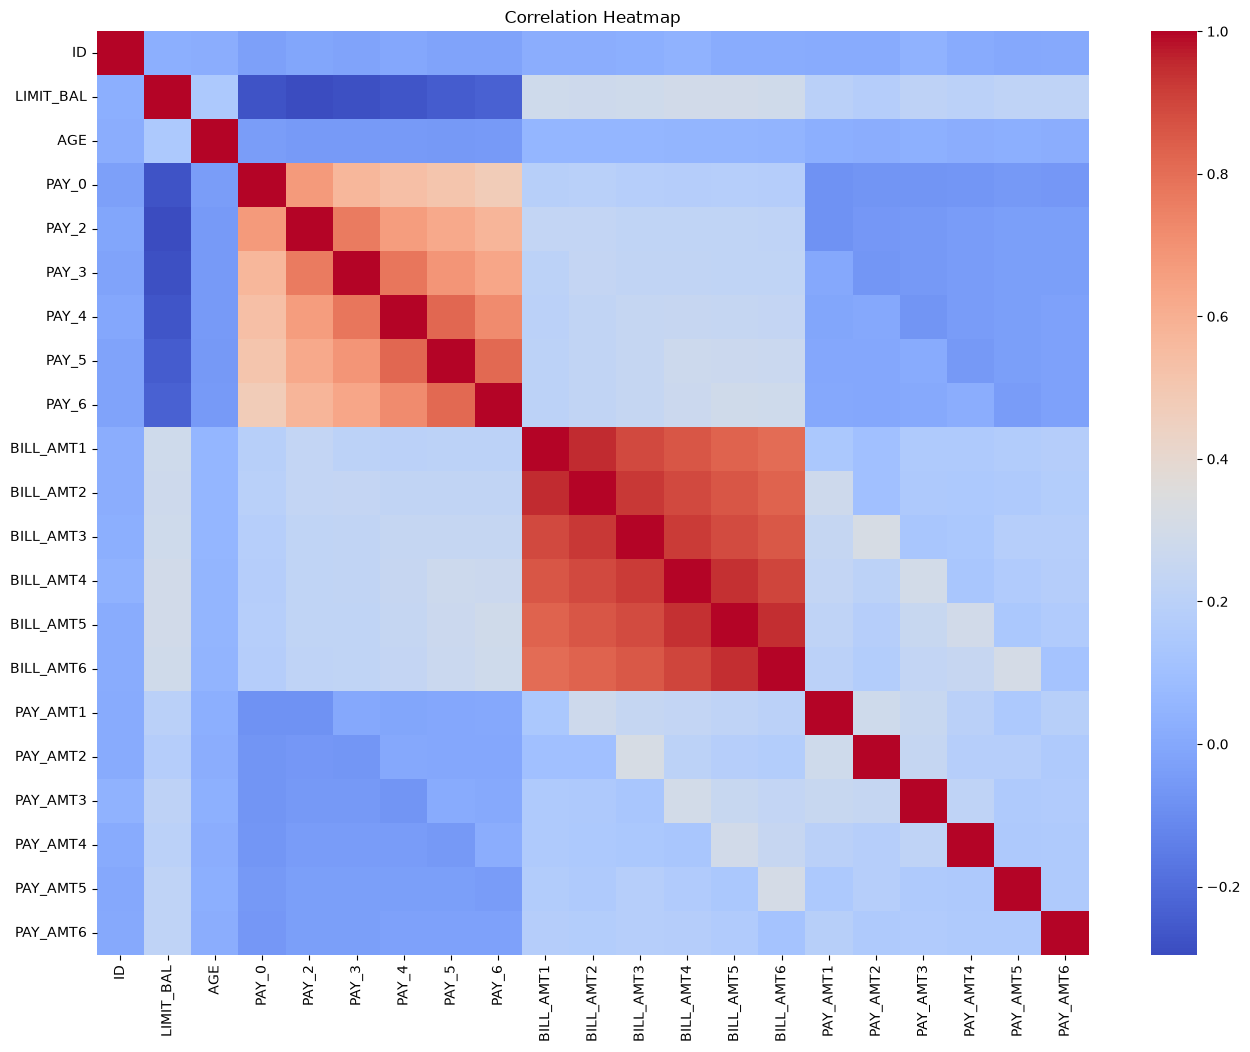

In [34]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False
)

plt.title('Correlation Heatmap')
plt.show()

# EDA Conclusion:
 The dataset contains 30,000 customer records and 25 columns. There are no missing values or duplicate records. The target variable is imbalanced, with approximately 77.88% non-default customers and 22.12% default customers. The dataset contains both numerical and categorical features. Payment history, bill amounts, payment amounts, demographic information, and credit limit will be further processed and analyzed to build the classification models.

# Data Preprocessing

In [35]:
df.columns = df.columns.str.strip()

df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default'],
      dtype='str')

In [36]:
df.isnull().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

In [37]:
df.isnull().sum().sum()

np.int64(0)

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df['default'] = df['default'].map({
    'N': 0,
    'Y': 1
})

In [40]:
df['default'].value_counts()

default
0    23364
1     6636
Name: count, dtype: int64

In [41]:
df = df.drop('ID', axis=1)

In [42]:
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000,F,University,Married,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,F,University,Single,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,F,University,Single,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,F,University,Married,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,M,University,Married,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [43]:
X = df.drop('default', axis=1)
y = df['default']

In [45]:
print(X.shape)
y.shape

(30000, 23)


(30000,)

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(24000, 23)
(6000, 23)
default
0    0.778792
1    0.221208
Name: proportion, dtype: float64
default
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [48]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE']
numerical_cols = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', StandardScaler(), numerical_cols)
    ]
)

In [51]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

In [52]:
print("X_train shape:", X_train_trans.shape)
print("X_test shape:", X_test_trans.shape)

X_train shape: (24000, 32)
X_test shape: (6000, 32)


In [53]:
bill_cols = [
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6'
]

df['AVG_BILL_AMT'] = df[bill_cols].mean(axis=1)

In [54]:
pay_amt_cols = [
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

df['AVG_PAY_AMT'] = df[pay_amt_cols].mean(axis=1)

In [55]:
df['TOTAL_BILL_AMT'] = df[bill_cols].sum(axis=1)

In [56]:
df['TOTAL_PAY_AMT'] = df[pay_amt_cols].sum(axis=1)

In [57]:
df[
    ['AVG_BILL_AMT', 'AVG_PAY_AMT',
     'TOTAL_BILL_AMT', 'TOTAL_PAY_AMT']
].head()

,AVG_BILL_AMT,AVG_PAY_AMT,TOTAL_BILL_AMT,TOTAL_PAY_AMT
0,1284.000000,114.833333,7704,689
1,2846.166667,833.333333,17077,5000
2,16942.166667,1836.333333,101653,11018
3,38555.666667,1398.000000,231334,8388
4,18223.166667,9841.500000,109339,59049


In [58]:
df['PAY_BILL_RATIO'] = (
    df['TOTAL_PAY_AMT'] /
    (df['TOTAL_BILL_AMT'].abs() + 1)
)

In [59]:
df['PAY_BILL_RATIO'].describe()

count     30000.000000
mean         21.216778
std        1255.766173
min           0.000000
25%           0.041302
50%           0.087865
75%           0.608768
max      162000.000000
Name: PAY_BILL_RATIO, dtype: float64

In [60]:
X = df.drop('default', axis=1)
y = df['default']

In [61]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 28)
y shape: (30000,)


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
new_numeric_cols = [
    'AVG_BILL_AMT',
    'AVG_PAY_AMT',
    'TOTAL_BILL_AMT',
    'TOTAL_PAY_AMT',
    'PAY_BILL_RATIO'
]

In [64]:
numerical_cols = [
    'LIMIT_BAL', 'AGE',
    'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
    'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
    'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
    'AVG_BILL_AMT',
    'AVG_PAY_AMT',
    'TOTAL_BILL_AMT',
    'TOTAL_PAY_AMT',
    'PAY_BILL_RATIO'
]

In [65]:
categorical_cols = [
    'SEX',
    'EDUCATION',
    'MARRIAGE'
]

In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), categorical_cols),
        ('num', RobustScaler(), numerical_cols)
    ]
)

In [103]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)
print("X_train shape:", X_train_trans.shape)
print("X_test shape:", X_test_trans.shape)

X_train shape: (24000, 37)
X_test shape: (6000, 37)


In [ ]:
from sklearn.feature_selection import mutual_info_classif

In [105]:
mi_scores = mutual_info_classif(
    X_train_trans,
    y_train,
    random_state=42
)

In [106]:
feature_names = preprocessor.get_feature_names_out()

In [107]:
mi_df = pd.DataFrame({
    'Feature': feature_names,
    'MI_Score': mi_scores
})

In [108]:
mi_df = mi_df.sort_values(
    by='MI_Score',
    ascending=False
)

In [ ]:
mi_df

,Feature,MI_Score
14,num__PAY_0,0.076772
15,num__PAY_2,0.054961
16,num__PAY_3,0.038675
17,num__PAY_4,0.036186
18,num__PAY_5,0.029650
19,num__PAY_6,0.027558
26,num__PAY_AMT1,0.024591
12,num__LIMIT_BAL,0.021343
35,num__TOTAL_PAY_AMT,0.018610
27,num__PAY_AMT2,0.018574


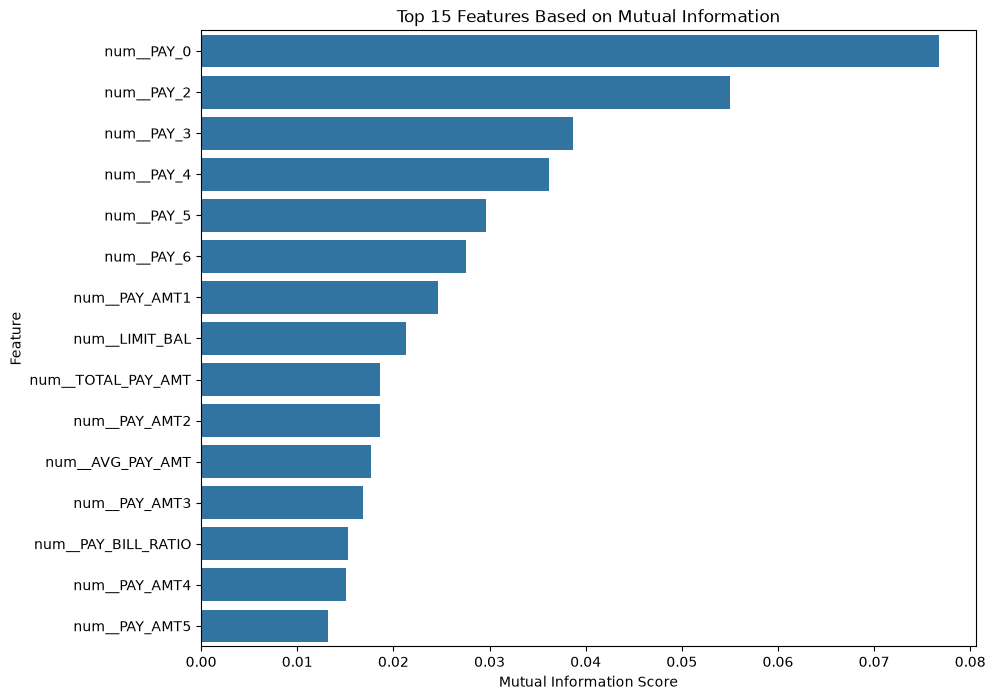

In [110]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x='MI_Score',
    y='Feature',
    data=mi_df.head(15)
)

plt.title('Top 15 Features Based on Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')
plt.show()

In [111]:
selected_features = mi_df.head(15)['Feature'].tolist()

selected_features

['num__PAY_0',
 'num__PAY_2',
 'num__PAY_3',
 'num__PAY_4',
 'num__PAY_5',
 'num__PAY_6',
 'num__PAY_AMT1',
 'num__LIMIT_BAL',
 'num__TOTAL_PAY_AMT',
 'num__PAY_AMT2',
 'num__AVG_PAY_AMT',
 'num__PAY_AMT3',
 'num__PAY_BILL_RATIO',
 'num__PAY_AMT4',
 'num__PAY_AMT5']

In [112]:
selected_indices = [
    list(feature_names).index(feature)
    for feature in selected_features
]

In [113]:
X_train_selected = X_train_trans[:, selected_indices]
X_test_selected = X_test_trans[:, selected_indices]

In [114]:
print("Original features:", X_train_trans.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 37
Selected features: 15


In [115]:
print("Original features:", X_train_trans.shape[1])
print("Selected features:", X_train_selected.shape[1])

Original features: 37
Selected features: 15


In [116]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [117]:
param_grid = {
    'n_neighbors': range(1, 21),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

In [118]:
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [119]:
knn_grid.fit(X_train_selected, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 21), 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see 

In [120]:
print("Best Parameters:")
print(knn_grid.best_params_)

Best Parameters:
{'n_neighbors': 9, 'p': 1, 'weights': 'distance'}


In [121]:
print("Best F1 Score:", knn_grid.best_score_)

Best F1 Score: 0.45629537428419303


In [122]:
KNeighborsClassifier(
    n_neighbors=14,
    p=2,
    weights='distance'
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None


In [123]:
print("Best Parameters:", knn_grid.best_params_)
print("Best F1 Score:", knn_grid.best_score_)

Best Parameters: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
Best F1 Score: 0.45629537428419303


In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_selected, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best F1 Score:", lr_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters: {'C': 10, 'solver': 'lbfgs'}
Best F1 Score: 0.3587535170418174


In [125]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_train_selected, y_train)

print("Best Parameters:", dt_grid.best_params_)
print("Best F1 Score:", dt_grid.best_score_)

Fitting 5 folds for each of 63 candidates, totalling 315 fits
Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score: 0.4683429158740422


In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_selected, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best F1 Score:", rf_grid.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best F1 Score: 0.47150511456958144


In [127]:
# Get the best models from hyperparameter tuning

knn_model = knn_grid.best_estimator_
lr_model = lr_grid.best_estimator_
dt_model = dt_grid.best_estimator_
rf_model = rf_grid.best_estimator_

In [128]:
# Train KNN
knn_model.fit(X_train_selected, y_train)

# Train Logistic Regression
lr_model.fit(X_train_selected, y_train)

# Train Decision Tree
dt_model.fit(X_train_selected, y_train)

# Train Random Forest
rf_model.fit(X_train_selected, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [129]:
print("KNN Model:", knn_model)
print("Logistic Regression Model:", lr_model)
print("Decision Tree Model:", dt_model)
print("Random Forest Model:", rf_model)

KNN Model: KNeighborsClassifier(n_neighbors=9, p=1, weights='distance')
Logistic Regression Model: LogisticRegression(C=10, max_iter=1000)
Decision Tree Model: DecisionTreeClassifier(max_depth=3, random_state=42)
Random Forest Model: RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=10,
                       n_jobs=-1, random_state=42)


In [130]:
# Predictions from all models

y_pred_knn = knn_model.predict(X_test_selected)
y_pred_lr = lr_model.predict(X_test_selected)
y_pred_dt = dt_model.predict(X_test_selected)
y_pred_rf = rf_model.predict(X_test_selected)

In [131]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# KNN
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1-Score:", f1_score(y_test, y_pred_knn))

# Logistic Regression
print("\nLogistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))

# Decision Tree
print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-Score:", f1_score(y_test, y_pred_dt))

# Random Forest
print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))

KNN
Accuracy: 0.8085
Precision: 0.6072289156626506
Recall: 0.37980406932931426
F1-Score: 0.4673157162726008

Logistic Regression
Accuracy: 0.8098333333333333
Precision: 0.7030567685589519
Recall: 0.2426525998492841
F1-Score: 0.3607843137254902

Decision Tree
Accuracy: 0.8186666666666667
Precision: 0.6612685560053981
Recall: 0.36925395629238883
F1-Score: 0.4738878143133462

Random Forest
Accuracy: 0.8191666666666667
Precision: 0.6704225352112676
Recall: 0.35870384325546345
F1-Score: 0.46735395189003437


In [132]:
results = pd.DataFrame({
    'Model': [
        'KNN',
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,KNN,0.808500,0.607229,0.379804,0.467316
1,Logistic Regression,0.809833,0.703057,0.242653,0.360784
2,Decision Tree,0.818667,0.661269,0.369254,0.473888
3,Random Forest,0.819167,0.670423,0.358704,0.467354


In [133]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_accuracy_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_accuracy_gridsearch = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=rf_accuracy_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_accuracy_gridsearch.fit(X_train_selected, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_

In [134]:
print("Best Parameters:")
print(rf_accuracy_gridsearch.best_params_)

print("Best CV Accuracy:")
print(rf_accuracy_gridsearch.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Accuracy:
0.82075


In [135]:
rf_accuracy = rf_accuracy_gridsearch.best_estimator_

y_pred_rf_accuracy = rf_accuracy.predict(X_test_selected)

In [136]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf_accuracy))
print("Precision:", precision_score(y_test, y_pred_rf_accuracy))
print("Recall:", recall_score(y_test, y_pred_rf_accuracy))
print("F1-Score:", f1_score(y_test, y_pred_rf_accuracy))

Accuracy: 0.8188333333333333
Precision: 0.6724137931034483
Recall: 0.35267520723436324
F1-Score: 0.46267918932278795


In [137]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_selected, y_train)

y_pred = rf.predict(X_test_selected)

In [138]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Accuracy: 0.7941666666666667
Precision: 0.5363349131121643
Recall: 0.5116804822908817
F1-Score: 0.5237177015040494


In [139]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_selected, y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_e

In [140]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}


In [141]:
print("Best CV F1-Score:")
print(grid_search.best_score_)

Best CV F1-Score:
0.5428921601267549


In [142]:
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_selected)

In [143]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))

Accuracy: 0.7723333333333333
Precision: 0.4878655880522713
Recall: 0.5908063300678221
F1-Score: 0.534423994546694
